# XGBoost Experiments

#### Overview

This notebook evaluates the performance of the XGBoost model under different strategies for handling class imbalance.

The following approaches are considered:

- Baseline (no handling)
- Class Weight
- SMOTE
- SMOTEENN

To ensure a fair and consistent comparison, all experiments use:

- A shared preprocessing pipeline to prevent data leakage
- Stratified K-Fold cross-validation to preserve class distribution across folds
- A unified evaluation framework for consistent metric computation

All results are stored in a shared results table for comparison with other models.

## Setup

In [1]:
# Add project root to system path so we can import from src/
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent / "bank-deposit-prediction"
sys.path.append(str(PROJECT_ROOT))


# Standard libraries
import pandas as pd

# Modeling
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# Imbalanced learning tools
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Shared project modules
from src.shared import get_cv, get_preprocessing_steps, Pipeline
from src.evaluation import evaluate_model, save_results



## Data Loading
The dataset is loaded and split into features (X) and target variable (y),  
with the target encoded as binary values:
- 1 → "yes"
- 0 → "no"

In [2]:
data_path = PROJECT_ROOT / "data" / "raw" / "bank2.csv"

df = pd.read_csv(data_path, sep=';')

y = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['y'])

## Shared components

We use:
- A centralized preprocessing pipeline (no data leakage)
- Stratified K-Fold cross-validation for fair evaluation

In [3]:
# Get shared cross-validation strategy
cv = get_cv()

## XGBoost

### Baseline
We begin with the baseline model without applying any imbalance handling.

In [4]:
all_results = []

# Build baseline pipeline
xgb_baseline_pipeline = Pipeline(
    get_preprocessing_steps() +  # Apply preprocessing
    [('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

# Evaluate model
result_baseline  = evaluate_model("XGBoost", "Baseline", xgb_baseline_pipeline, X, y, cv)
all_results.append(result_baseline)
result_baseline

{'Model': 'XGBoost',
 'Strategy': 'Baseline',
 'Accuracy': '0.8830 ± 0.0048',
 'Precision': '0.4765 ± 0.0576',
 'Recall': '0.1784 ± 0.0353',
 'F1': '0.2590 ± 0.0447',
 'PR-AUC': '0.3037 ± 0.0329',
 'ROC-AUC': '0.7020 ± 0.0049'}

### Class Weight
Class weights are used to give more importance to the minority class during training.

In [5]:
# Compute class weight ratio
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

xgb_cw_pipeline = Pipeline(
    get_preprocessing_steps() +
    [('model', XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

result_cw = evaluate_model("XGBoost", "ClassWeight", xgb_cw_pipeline, X, y, cv)
all_results.append(result_cw)
result_cw

{'Model': 'XGBoost',
 'Strategy': 'ClassWeight',
 'Accuracy': '0.8498 ± 0.0070',
 'Precision': '0.3300 ± 0.0308',
 'Recall': '0.2936 ± 0.0394',
 'F1': '0.3099 ± 0.0313',
 'PR-AUC': '0.2791 ± 0.0381',
 'ROC-AUC': '0.6806 ± 0.0194'}

### SMOTE
SMOTE is applied to oversample the minority class and improve model sensitivity.

In [6]:
xgb_smote_pipeline = ImbPipeline(
    get_preprocessing_steps() +
    [('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

result_smote = evaluate_model("XGBoost", "SMOTE", xgb_smote_pipeline, X, y, cv)
all_results.append(result_smote)
result_smote

{'Model': 'XGBoost',
 'Strategy': 'SMOTE',
 'Accuracy': '0.8834 ± 0.0023',
 'Precision': '0.4829 ± 0.0311',
 'Recall': '0.1765 ± 0.0372',
 'F1': '0.2567 ± 0.0431',
 'PR-AUC': '0.3178 ± 0.0177',
 'ROC-AUC': '0.7172 ± 0.0150'}

### SMOTEENN
SMOTEENN is used as a hybrid approach to both oversample the minority class and remove noisy samples.

In [7]:
xgb_smoteenn_pipeline = ImbPipeline(
    get_preprocessing_steps() +
    [('smoteenn', SMOTEENN(random_state=42)),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

result_smoteenn = evaluate_model("XGBoost", "SMOTEENN", xgb_smoteenn_pipeline, X, y, cv)
all_results.append(result_smoteenn)

result_smoteenn

{'Model': 'XGBoost',
 'Strategy': 'SMOTEENN',
 'Accuracy': '0.8290 ± 0.0041',
 'Precision': '0.3266 ± 0.0061',
 'Recall': '0.4549 ± 0.0160',
 'F1': '0.3800 ± 0.0061',
 'PR-AUC': '0.3323 ± 0.0215',
 'ROC-AUC': '0.7270 ± 0.0142'}

### Results Summary

All experiment results are stored in a shared table for consistent comparison.

In [8]:
# Save results
results_df = pd.DataFrame(all_results)
save_results(results_df)

# Read experiment_results table
results_path = PROJECT_ROOT / "results" / "experiment_results.csv"
results = pd.read_csv(results_path)
results

,Model,Strategy,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
0,XGBoost,Baseline,0.8830 ± 0.0048,0.4765 ± 0.0576,0.1784 ± 0.0353,0.2590 ± 0.0447,0.3037 ± 0.0329,0.7020 ± 0.0049
1,XGBoost,ClassWeight,0.8498 ± 0.0070,0.3300 ± 0.0308,0.2936 ± 0.0394,0.3099 ± 0.0313,0.2791 ± 0.0381,0.6806 ± 0.0194
2,XGBoost,SMOTE,0.8834 ± 0.0023,0.4829 ± 0.0311,0.1765 ± 0.0372,0.2567 ± 0.0431,0.3178 ± 0.0177,0.7172 ± 0.0150
3,XGBoost,SMOTEENN,0.8290 ± 0.0041,0.3266 ± 0.0061,0.4549 ± 0.0160,0.3800 ± 0.0061,0.3323 ± 0.0215,0.7270 ± 0.0142
4,RandomForest,Baseline,0.8885 ± 0.0028,0.5940 ± 0.0983,0.1209 ± 0.0231,0.1989 ± 0.0308,0.3482 ± 0.0273,0.7333 ± 0.0184
5,RandomForest,ClassWeight,0.8910 ± 0.0049,0.6479 ± 0.1295,0.1151 ± 0.0303,0.1947 ± 0.0493,0.3418 ± 0.0378,0.7384 ± 0.0211
6,RandomForest,SMOTE,0.8848 ± 0.0051,0.5003 ± 0.0823,0.1516 ± 0.0294,0.2320 ± 0.0416,0.3234 ± 0.0372,0.7252 ± 0.0239
7,RandomForest,SMOTEENN,0.8275 ± 0.0083,0.3171 ± 0.0158,0.4281 ± 0.0186,0.3639 ± 0.0125,0.3064 ± 0.0331,0.7207 ± 0.0273
8,LogisticRegression,Baseline,0.8923 ± 0.0037,0.6605 ± 0.1145,0.1439 ± 0.0290,0.2342 ± 0.0399,0.3482 ± 0.0375,0.7247 ± 0.0143
9,LogisticRegression,ClassWeight,0.7125 ± 0.0128,0.2188 ± 0.0073,0.5815 ± 0.0427,0.3176 ± 0.0122,0.3407 ± 0.0344,0.7238 ± 0.0130


## Model Selection and Stability Analysis

In [9]:
# Function to split "mean ± std"
def split_mean_std(column):
    mean = column.str.split('±').str[0].astype(float)
    std  = column.str.split('±').str[1].astype(float)
    return mean, std

# Apply to needed columns
for col in ['Recall', 'F1', 'PR-AUC']:
    results[f'{col}_mean'], results[f'{col}_std'] = split_mean_std(results[col])

In [10]:
# Filter top 2 models
top_models = results[
    (results['Model'] == 'XGBoost') & (results['Strategy'] == 'SMOTEENN') |
    (results['Model'] == 'RandomForest') & (results['Strategy'] == 'SMOTEENN')
]
top_models

,Model,Strategy,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC,Recall_mean,Recall_std,F1_mean,F1_std,PR-AUC_mean,PR-AUC_std
3,XGBoost,SMOTEENN,0.8290 ± 0.0041,0.3266 ± 0.0061,0.4549 ± 0.0160,0.3800 ± 0.0061,0.3323 ± 0.0215,0.7270 ± 0.0142,0.4549,0.0160,0.3800,0.0061,0.3323,0.0215
7,RandomForest,SMOTEENN,0.8275 ± 0.0083,0.3171 ± 0.0158,0.4281 ± 0.0186,0.3639 ± 0.0125,0.3064 ± 0.0331,0.7207 ± 0.0273,0.4281,0.0186,0.3639,0.0125,0.3064,0.0331


In [11]:
# Metrics we want to compare across models
metrics = ['Recall', 'F1', 'PR-AUC']

# Filter results for each model
xgb = top_models[top_models['Model'] == 'XGBoost']
rf  = top_models[top_models['Model'] == 'RandomForest']

# Extract mean and standard deviation values for selected metrics (XGBoost)
xgb_mean = [xgb[f'{m}_mean'].values[0] for m in metrics]
xgb_std  = [xgb[f'{m}_std'].values[0] for m in metrics]

# Extract mean and standard deviation values for selected metrics (Random Forest)
rf_mean  = [rf[f'{m}_mean'].values[0] for m in metrics]
rf_std   = [rf[f'{m}_std'].values[0] for m in metrics]

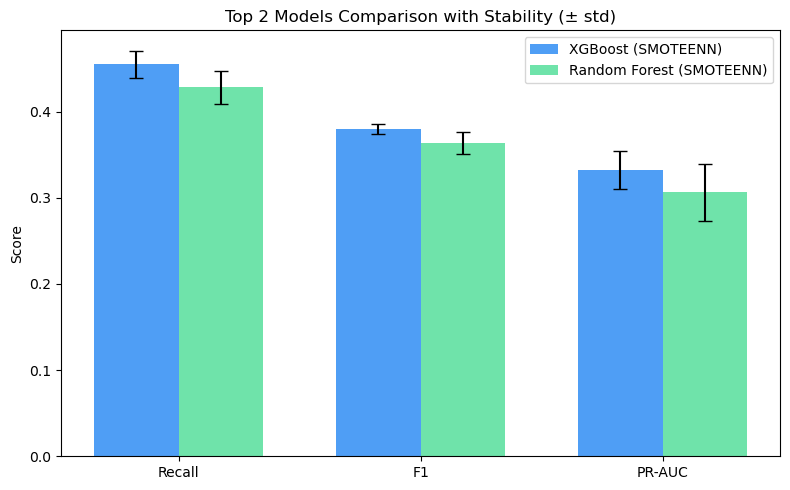

In [12]:
# Plot comparison of the top 2 models (XGBoost and Random Forest) across key metrics

import numpy as np
import matplotlib.pyplot as plt
# Plot 
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# Plot XGBoost results

ax.bar(x - width/2, xgb_mean, width, yerr=xgb_std, color="#4F9EF5",
       label='XGBoost (SMOTEENN)', capsize=5, ecolor='black')

# Plot Random Forest results 
ax.bar(x + width/2, rf_mean, width, yerr=rf_std, color='#6FE3AA',
       label='Random Forest (SMOTEENN)', capsize=5 , ecolor='black')


ax.set_ylabel('Score')
ax.set_title('Top 2 Models Comparison with Stability (± std)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.legend()

plt.tight_layout()
plt.savefig("top_models_comparison.png", dpi=300)
plt.show()

## Model Analysis and Interpretation

This section focuses on analyzing and interpreting the best-performing model, XGBoost with SMOTEENN. 

Feature importance is first examined to identify the most influential variables, followed by SHAP analysis to provide a deeper understanding of how features influence the model’s predictions. 

In addition, threshold optimization is performed to determine decision thresholds that maximize business profit under different scenarios.

### Setup

In [13]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline as ImbPipeline
from src.shared import drop_columns, transform_pdays


final_model= xgb_smoteenn_pipeline
final_model.fit(X, y);


### Feature Importance
The following plot shows the top features based on the XGBoost model’s importance scores.

In [14]:
# Get feature names after preprocessing
preprocessor = final_model.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [15]:
# Extract the trained XGBoost from the pipeline
xgb_model = final_model.named_steps['model']  

In [16]:
# Get feature importance scores and sort them
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Display top 10 most important features
xgb_importance.head(10)

cat__contact_unknown        0.100306
cat__poutcome_success       0.058690
cat__marital_married        0.050558
cat__housing_yes            0.044199
cat__job_services           0.040672
cat__contact_cellular       0.040573
cat__job_technician         0.036766
cat__month_jun              0.036054
cat__month_jul              0.026768
cat__education_secondary    0.026488
dtype: float32

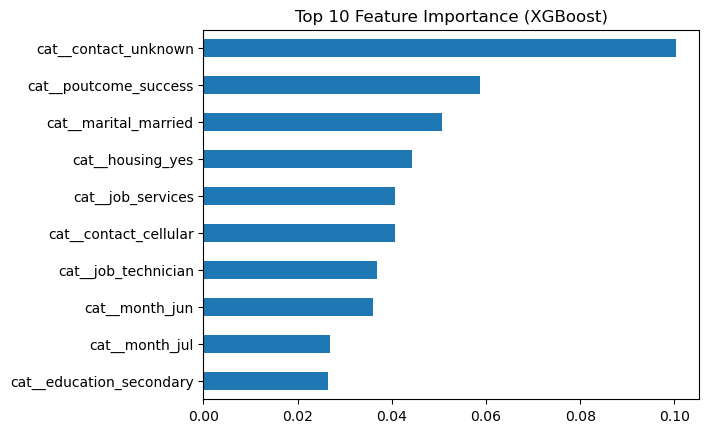

In [17]:
# Plot top 10 feature importance
xgb_importance.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

### SHAP Analysis
SHAP (SHapley Additive exPlanations) is used to provide a more detailed interpretation of feature contributions, showing how each feature influences the model’s predictions.

⌛ Running SHAP analysis...
Generating SHAP Analysis for XGBoost SMOTEENN...


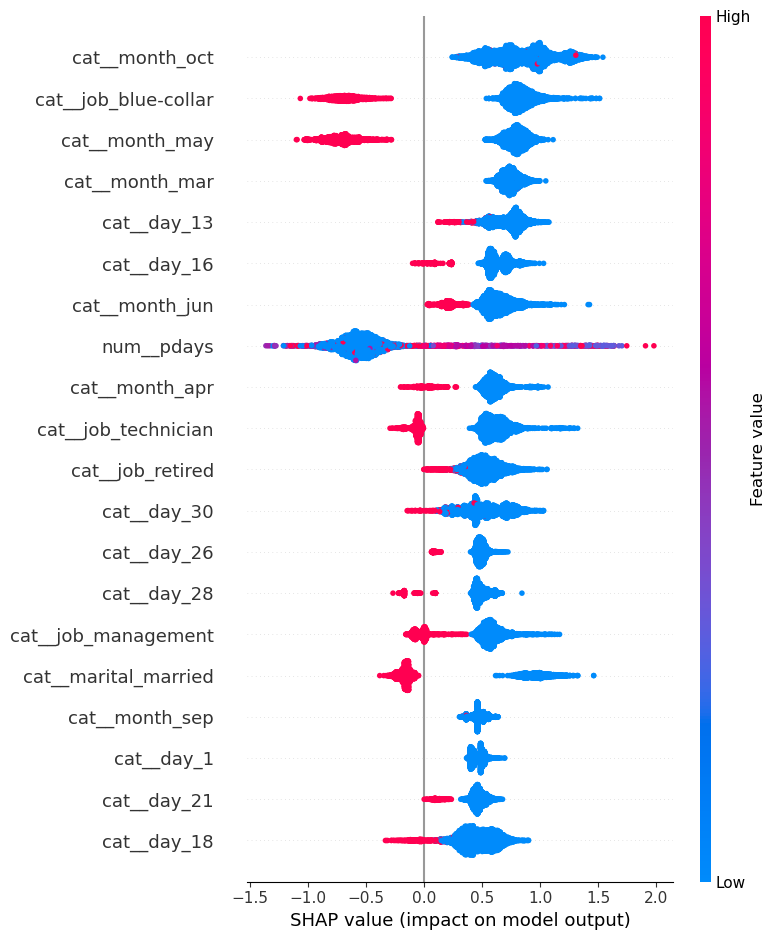

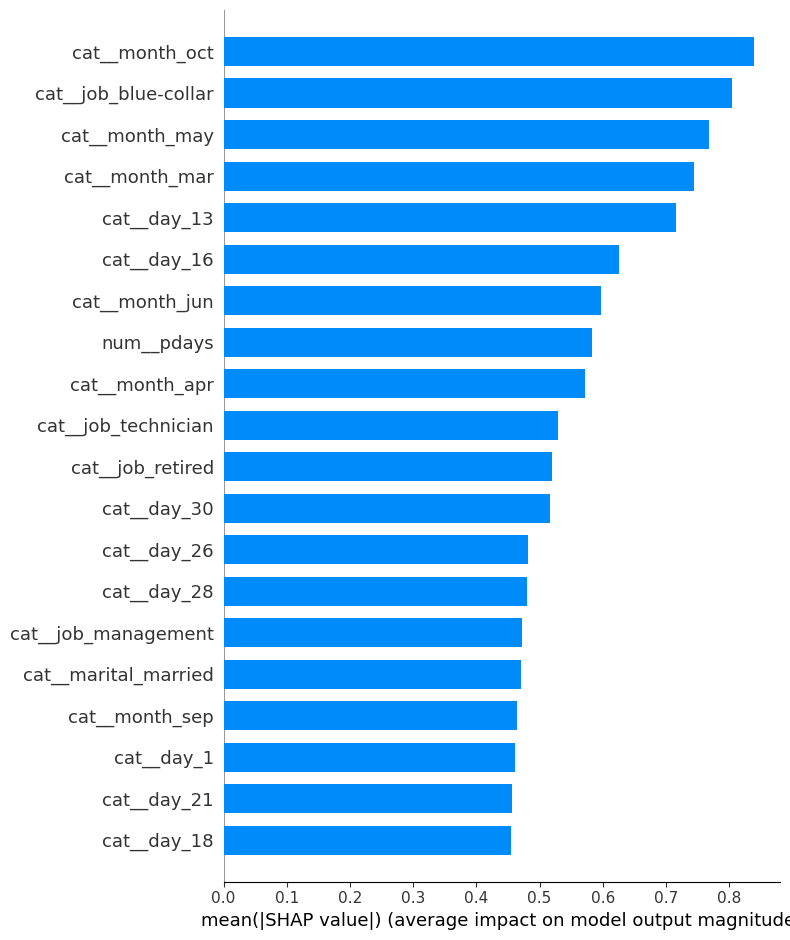

In [18]:
print("⌛ Running SHAP analysis...")
#  Apply preprocessing 
X_temp = final_model.named_steps['drop_columns'].transform(X)
X_temp = final_model.named_steps['pdays_transform'].transform(X_temp)

X_transformed = final_model.named_steps['preprocessor'].transform(X_temp)

#  Convert sparse → dense 
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()
else:
    X_transformed = X_transformed

#  Get feature names
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

#  Convert to DataFrame
X_df = pd.DataFrame(X_transformed, columns=feature_names)

# Extract model
xgb_model = final_model.named_steps['model']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_df)

# Final Summary Plot
print("Generating SHAP Analysis for XGBoost SMOTEENN...")
# Note: For XGBoost, we usually just pass shap_values directly
shap.summary_plot(shap_values, X_df)
shap.summary_plot(shap_values, X_df, plot_type="bar")

### Threshold Optimization

This section explores different classification thresholds for the XGBoost model to maximize profit.

- The model is evaluated across thresholds with a step of 0.01  
- Different cost scenarios are tested to assess the impact on estimated profit

In [19]:
# Define business cost scenarios (TP = gain, FP/FN = cost)
scenarios = {
    "Aggressive": {"TP": 120, "FP": -15, "FN": -120},
    "Balanced": {"TP": 100, "FP": -20, "FN": -100},
    "Conservative": {"TP": 100, "FP": -50, "FN": -80}
}

def calculate_profit(y_true, y_pred, TP, FP, FN):
    tp_count = np.sum((y_true == 1) & (y_pred == 1))
    fp_count = np.sum((y_true == 0) & (y_pred == 1))
    fn_count = np.sum((y_true == 1) & (y_pred == 0))
    return (tp_count * TP + fp_count * FP + fn_count * FN) / len(y_true)

In [20]:
# Get predicted probabilities for the positive class (y = 1)

y_probs = final_model.predict_proba(X)[:, 1]

In [21]:
scenario_thresholds = {name: [] for name in scenarios.keys()}

# Run the loop 
for train_index, val_index in cv.split(X, y):
    # Split the data
    X_v_train, X_v_val = X.iloc[train_index], X.iloc[val_index]
    y_v_train, y_v_val = y.iloc[train_index], y.iloc[val_index]
    
    # Fit the model
    final_model.fit(X_v_train, y_v_train)
    
    # Get probabilities for the validation fold
    y_probs_val = final_model.predict_proba(X_v_val)[:, 1]
    
   # Inner loop through each business scenario
    for name, costs in scenarios.items():
        fold_results = []
        for t in np.linspace(0.01, 0.99, 99):
            y_pred = (y_probs_val >= t).astype(int)
            # Pass specific costs for this scenario
            profit = calculate_profit(y_v_val, y_pred, costs['TP'], costs['FP'], costs['FN'])
            fold_results.append((t, profit))
        
        # Pick the best t for this specific scenario in this fold
        best_t = max(fold_results, key= lambda x: x[1])[0]
        scenario_thresholds[name].append(best_t)

#  Aggregate and Display Results
print("--- Optimal Thresholds by Scenario ---")
final_thresholds = {}

for name, t_list in scenario_thresholds.items():
    t_mean = np.mean(t_list)
    t_std = np.std(t_list)
    final_thresholds[name] = t_mean # Saving for later use
    print(f"{name:12}: {t_mean:.4f} ± {t_std:.4f}")

--- Optimal Thresholds by Scenario ---
Aggressive  : 0.0560 ± 0.0242
Balanced    : 0.1740 ± 0.1127
Conservative: 0.6680 ± 0.0703


In [22]:
# Assuming you have y_probs from your final trained model
# and scenario_thresholds from the previous step

results_summary = []

for name, t_list in scenario_thresholds.items():
    t_opt = np.mean(t_list)  # This is your Optimal Threshold for the scenario
    
    # Calculate predictions based on this optimal threshold
    y_pred = (y_probs >= t_opt).astype(int)
    
    # Get the costs for this specific scenario
    costs = scenarios[name]
    
    # Calculate the profit
    final_profit = calculate_profit(y, y_pred, costs['TP'], costs['FP'], costs['FN'])
    
    results_summary.append({
        'Scenario': name,
        'Optimal Threshold': round(t_opt, 4),
        'Estimated Profit': round(final_profit, 2)
    })

# Display as a clean DataFrame
profit_df = pd.DataFrame(results_summary)
print(profit_df)

       Scenario  Optimal Threshold  Estimated Profit
0    Aggressive              0.056              6.21
1      Balanced              0.174              5.90
2  Conservative              0.668              1.02


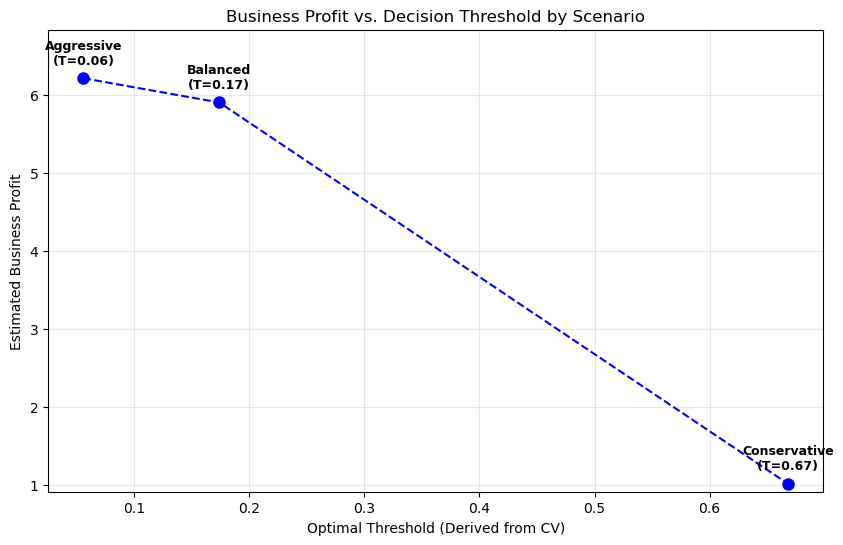

In [23]:
# Extract names, thresholds, and profits into lists for plotting
scenario_names = list(final_thresholds.keys()) # ['Aggressive', 'Balanced', 'Conservative']
threshold_vals = [final_thresholds[name] for name in scenario_names]
profit_vals = [profit_df.loc[profit_df['Scenario'] == name, 'Estimated Profit'].values[0] for name in scenario_names]

#  Run the Plot
plt.figure(figsize=(10, 6))

# Plot the points
plt.plot(threshold_vals, profit_vals, marker='o', linestyle='--', color='b', markersize=8)

# Annotate each point so you know which scenario is which
for i, name in enumerate(scenario_names):
    plt.annotate(f"{name}\n(T={threshold_vals[i]:.2f})", 
                 (threshold_vals[i], profit_vals[i]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center',
                 fontsize=9,
                 fontweight='bold')

plt.xlabel("Optimal Threshold (Derived from CV)")
plt.ylabel("Estimated Business Profit")
plt.title("Business Profit vs. Decision Threshold by Scenario")
plt.ylim(min(profit_vals) * 0.9, max(profit_vals) * 1.1) # Add some padding to see points clearly
plt.grid(True, alpha=0.3)
plt.show()